In [1]:
import scanpy as sc
"""
Fast, compact spatial plotting function for AnnData objects.

This function creates multi-panel spatial plots grouped by a specified column (e.g., sample_id),
with support for both categorical and continuous color schemes, highlighting, and custom layouts.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors
import scanpy as sc
from pandas.api.types import is_numeric_dtype, is_categorical_dtype
from scipy.sparse import issparse


def plot_spatial_compact_fast(
    ad,
    color="leiden_2",       # obs column *or* gene name
    groupby="sample_id",
    spot_size=8,
    cols=3,
    height=8,
    legend_col_width=1.2,
    palette=None,
    rasterized=True,
    invert_y=True,
    dpi=120,
    highlight=None,
    group_order=None,
    background="white",
    grey_alpha=0.2,         # alpha for non-highlighted categories
    vmin=None,
    vmax=None,
    cmap_name="viridis",
    shared_scale=False,     # if True: vmin/vmax from whole `ad` (not per subset)
):
    """
    Plot spatial data in a compact multi-panel layout.

    Parameters
    ----------
    ad : AnnData
        Annotated data object with spatial coordinates in ad.obsm['spatial']
    color : str
        Column in ad.obs or gene name in ad.var_names to color by
    groupby : str
        Column in ad.obs to group panels by (e.g., 'sample_id')
    spot_size : float
        Size of scatter points
    cols : int
        Number of columns in the grid layout
    height : float
        Figure height in inches
    legend_col_width : float
        Width allocated for legend/colorbar column
    palette : dict, list, or str, optional
        Color palette for categorical data or colormap name for continuous
    rasterized : bool
        Whether to rasterize scatter plots (recommended for large datasets)
    invert_y : bool
        Whether to invert y-axis (common for imaging coordinates)
    dpi : int
        Figure DPI
    highlight : str, list, optional
        For categorical data: which categories to highlight (others are greyed)
    group_order : list, optional
        Custom order for groups (panels)
    background : str
        Background color ('white' or 'black')
    grey_alpha : float
        Alpha value for non-highlighted categories (0-1)
    vmin : float, optional
        Minimum value for continuous color scale
    vmax : float, optional
        Maximum value for continuous color scale
    cmap_name : str
        Colormap name for continuous data
    shared_scale : bool
        If True, use same vmin/vmax across all panels for continuous data

    Returns
    -------
    None
        Displays the plot
    """
    # pick background + text color
    fig_face = background
    ax_face = background
    text_color = "white" if background in ("black", "#000000", "k") else "black"

    # ----- 0) Preconditions -----
    if "spatial" not in ad.obsm:
        raise ValueError("ad.obsm['spatial'] not found")

    if groupby not in ad.obs.columns:
        raise KeyError(f"groupby {groupby!r} not in ad.obs")

    # decide where 'color' comes from: obs vs var (gene)
    if color in ad.obs.columns:
        color_source = "obs"
        col_series = ad.obs[color]
    elif color in ad.var_names:
        color_source = "var"   # gene expression
        col_series = None
    else:
        raise KeyError(
            f"{color!r} not found in ad.obs.columns or ad.var_names "
            "(expected an obs column or a gene name)."
        )

    coords = np.asarray(ad.obsm["spatial"])[:, :2]

    # Detect continuous vs categorical
    if color_source == "var":
        # genes: always continuous
        is_continuous = True
    else:
        if is_categorical_dtype(col_series):
            is_continuous = False
        else:
            is_continuous = is_numeric_dtype(col_series)

    # ----------------------------------------------------
    # 1) Build colors_arr differently for cont vs cat
    # ----------------------------------------------------
    if is_continuous:
        # ===== CONTINUOUS MODE =====
        if color_source == "obs":
            vals = col_series.to_numpy(dtype=float)
        else:
            # from var / gene expression
            gene_idx = ad.var_names.get_loc(color)
            x = ad.X[:, gene_idx]
            if issparse(x):
                vals = x.toarray().ravel()
            else:
                vals = np.asarray(x).ravel()

        # choose colormap
        if palette is None:
            cmap = plt.get_cmap(cmap_name)
        elif isinstance(palette, str):
            cmap = plt.get_cmap(palette)
        else:
            cmap = palette

        # ----- determine vmin/vmax -----
        if shared_scale:
            # global min/max across the *full AnnData* passed to this function
            full = ad
            if color_source == "var":
                gx = full.X[:, full.var_names.get_loc(color)]
                if issparse(gx):
                    full_vals = gx.toarray().ravel()
                else:
                    full_vals = np.asarray(gx).ravel()
            else:
                full_vals = pd.to_numeric(full.obs[color], errors="coerce").to_numpy()

            finite_full = np.isfinite(full_vals)
            if finite_full.sum() == 0:
                raise ValueError(f"All values for '{color}' are NaN or non-finite.")
            vmin_use = float(np.min(full_vals[finite_full]))
            vmax_use = float(np.max(full_vals[finite_full]))
        else:
            finite_mask = np.isfinite(vals)
            if finite_mask.sum() == 0:
                raise ValueError(f"All values for '{color}' are NaN or non-finite.")
            vmin_use = float(np.min(vals[finite_mask]))
            vmax_use = float(np.max(vals[finite_mask]))

        # user overrides everything
        if vmin is not None:
            vmin_use = float(vmin)
        if vmax is not None:
            vmax_use = float(vmax)

        # avoid zero-range
        if vmin_use == vmax_use:
            vmin_use -= 1.0
            vmax_use += 1.0

        norm = mcolors.Normalize(vmin=vmin_use, vmax=vmax_use)

        colors_arr = np.zeros((vals.size, 4), dtype=float)
        finite_mask = np.isfinite(vals)
        colors_arr[finite_mask] = cmap(norm(vals[finite_mask]))
        colors_arr[~finite_mask] = (0, 0, 0, 0)

        # store continuous settings in uns (also fine for genes)
        ad.uns[f"{color}_continuous"] = {
            "vmin": float(vmin_use),
            "vmax": float(vmax_use),
            "cmap": cmap.name if hasattr(cmap, "name") else str(cmap),
        }

        cat_names = None
        cat_codes = None

    else:
        # ===== CATEGORICAL (only for obs) =====
        # preserve existing categorical order if present
        if is_categorical_dtype(col_series):
            cats = col_series.cat.remove_unused_categories()
        else:
            cats = col_series.astype("category")

        cat_names = cats.cat.categories
        cat_codes = cats.cat.codes.to_numpy()

        # palette handling
        if isinstance(palette, dict):
            col_list = [palette[c] for c in cat_names]
        elif isinstance(palette, (list, tuple)):
            if len(palette) < len(cat_names):
                raise ValueError("Palette shorter than number of categories.")
            col_list = list(palette)[:len(cat_names)]
        elif f"{color}_colors" in ad.uns:
            col_list = list(ad.uns[f"{color}_colors"])
            if len(col_list) != len(cat_names):
                raise ValueError(f"{color}_colors length != categories.")
        else:
            base = list(
                sc.pl.palettes.default_64
                if hasattr(sc.pl.palettes, "default_64")
                else sc.pl.palettes.default_102
            )
            reps = int(np.ceil(len(cat_names) / len(base)))
            col_list = (base * reps)[:len(cat_names)]

        ad.uns[f"{color}_colors"] = col_list

        rgba = np.array([mcolors.to_rgba(c) for c in col_list], dtype=float)

        colors_arr = np.empty((cat_codes.size, 4), dtype=float)
        colors_arr[cat_codes >= 0] = rgba[cat_codes[cat_codes >= 0]]
        colors_arr[cat_codes < 0] = (0, 0, 0, 0)

        # ----- highlighting logic -----
        if highlight is not None:
            # allow single value or list/tuple/array
            if not isinstance(highlight, (list, tuple, set, np.ndarray)):
                highlight = [highlight]
            # convert to string for robust matching
            highlight_str = {str(h) for h in highlight}

            cat_name_str = np.array([str(c) for c in cat_names])
            keep_cat_mask = np.isin(cat_name_str, list(highlight_str))  # per-category

            # use user-defined alpha for greyed-out categories
            grey_rgba = (0.8, 0.8, 0.8, float(grey_alpha))

            valid = cat_codes >= 0
            keep_flag = np.zeros_like(cat_codes, dtype=bool)
            keep_flag[valid] = keep_cat_mask[cat_codes[valid]]

            # grey out all non-highlighted cells
            colors_arr[valid & ~keep_flag] = grey_rgba

            # also grey in legend
            col_list = [
                col_list[k] if keep_cat_mask[k] else mcolors.to_hex(grey_rgba)
                for k in range(len(cat_names))
            ]

    # ----------------------------------------------------
    # 2) Precompute group indices (RESPECT ORDERED CATEGORICAL)
    # ----------------------------------------------------
    gser = ad.obs[groupby]

    if group_order is not None:
        group_order = [str(g) for g in group_order]
        present = set(gser.astype(str))
        uniq_groups = [g for g in group_order if g in present]
    else:
        # if groupby is an ordered categorical, respect its category order
        if is_categorical_dtype(gser) and gser.cat.ordered:
            cats = list(gser.cat.categories)
            present = set(gser.astype(str))
            uniq_groups = [str(c) for c in cats if str(c) in present]
        else:
            # fallback: sorted unique strings
            uniq_groups = sorted(gser.astype(str).unique())

    gvals = gser.astype(str).to_numpy()
    gid_to_idx = {g: i for i, g in enumerate(uniq_groups)}
    gcodes = np.array([gid_to_idx.get(g, -1) for g in gvals], dtype=int)

    group_indices = [np.flatnonzero(gcodes == gi) for gi in range(len(uniq_groups))]

    # ----------------------------------------------------
    # 3) Figure layout
    # ----------------------------------------------------
    n = len(uniq_groups)
    rows = int(np.ceil(n / cols))
    panel_w = height * cols * 0.6 / rows
    fig_w = panel_w + legend_col_width

    plt.ioff()
    fig = plt.figure(figsize=(fig_w, height), dpi=dpi, constrained_layout=False)

    # background for figure
    fig.patch.set_facecolor(fig_face)

    gs = GridSpec(
        rows, cols + 1, figure=fig,
        width_ratios=[1]*cols + [legend_col_width / (fig_w - legend_col_width)],
        wspace=0.02, hspace=0.02
    )

    # ----------------------------------------------------
    # 4) Panels
    # ----------------------------------------------------
    for i, sid in enumerate(uniq_groups):
        r, c = divmod(i, cols)
        ax = fig.add_subplot(gs[r, c])

        # panel background
        ax.set_facecolor(ax_face)

        idx = group_indices[i]
        if idx.size:
            xy = coords[idx]
            ax.scatter(
                xy[:, 0], -xy[:, 1],
                c=colors_arr[idx],
                s=spot_size,
                marker='o',
                linewidths=0,
                rasterized=rasterized
            )

        meta_strings = []

        if "region" in ad.obs.columns:
            region_vals = (
                ad.obs.loc[ad.obs[groupby] == sid, "region"]
                .dropna().astype(str).unique()
            )
            if len(region_vals) == 0:
                meta_strings.append("Region: unknown")
            elif len(region_vals) == 1:
                meta_strings.append(f"Region: {region_vals[0]}")
            else:
                meta_strings.append("Region: mixed")

        if "course" in ad.obs.columns:
            course_vals = (
                ad.obs.loc[ad.obs[groupby] == sid, "course"]
                .dropna().astype(str).unique()
            )
            if len(course_vals) == 0:
                meta_strings.append("Course: unknown")
            elif len(course_vals) == 1:
                meta_strings.append(f"Course: {course_vals[0]}")
            else:
                meta_strings.append("Course: mixed")

        if meta_strings:
            title = f"{sid}\n[{ ' | '.join(meta_strings) }]"
        else:
            title = str(sid)

        ax.set_title(title, fontsize=5, pad=2, color=text_color)
        ax.set_aspect("equal")
        if invert_y:
            ax.invert_yaxis()
        ax.set_axis_off()

    # blank unused panels
    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        ax = fig.add_subplot(gs[r, c])
        ax.set_facecolor(ax_face)
        ax.axis("off")

    # ----------------------------------------------------
    # 5) Legend / Colorbar
    # ----------------------------------------------------
    ax_leg = fig.add_subplot(gs[:, -1])
    ax_leg.set_facecolor(ax_face)
    ax_leg.axis("off")

    if is_continuous:
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cbar = fig.colorbar(sm, cax=ax_leg)
        cbar.set_label(color, rotation=90, color=text_color)
        cbar.ax.yaxis.set_tick_params(color=text_color)
        plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color=text_color)
    else:
        handles = [
            Line2D(
                [0], [0], marker="o", color="w",
                markerfacecolor=col_list[k], markersize=7, label=str(cat)
            )
            for k, cat in enumerate(cat_names)
        ]
        leg = ax_leg.legend(
            handles=handles,
            title=color,
            frameon=False,
            loc="center left",
            labelcolor=text_color,
            title_fontsize=10
        )
        leg.get_title().set_color(text_color)
        for text in leg.get_texts():
            text.set_color(text_color)

    fig.subplots_adjust(
        left=0.01, right=0.98, top=0.98, bottom=0.02,
        wspace=0.02, hspace=0.02
    )

    plt.ion()
    plt.show()


/Users/christoffer/miniconda3/envs/cellcharter310/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
ad = sc.read_h5ad('/Volumes/processing2/oligo-mtDSB/data/mtDNA_DSB_5k_clustered_annotation_MANA.h5ad')

In [3]:
import pandas as pd
from pandas.api.types import is_categorical_dtype

# Order sample_id by age, then condition
sample_key = 'sample_id'
age_key = 'age'
condition_key = 'condition'

missing = [k for k in (sample_key, age_key, condition_key) if k not in ad.obs]
if missing:
    raise KeyError(f"Missing columns in ad.obs: {missing}")

meta = ad.obs[[sample_key, age_key, condition_key]].copy()
meta[sample_key] = meta[sample_key].astype(str)

# Warn if a sample_id maps to multiple age/condition values
nuniq = meta.groupby(sample_key)[[age_key, condition_key]].nunique()
if (nuniq > 1).any().any():
    print('Warning: some sample_id have multiple age/condition values')

# Build condition order (respect ordered categoricals if present)
cond_ser = meta[condition_key]
if is_categorical_dtype(cond_ser) and cond_ser.cat.ordered:
    cond_order = {c: i for i, c in enumerate(cond_ser.cat.categories)}
    cond_sort = cond_ser.map(cond_order)
else:
    cond_order = {c: i for i, c in enumerate(sorted(cond_ser.astype(str).unique()))}
    cond_sort = cond_ser.astype(str).map(cond_order)

# Build age order (prefer ordered categorical; else numeric if possible; else string)
age_ser = meta[age_key]
if is_categorical_dtype(age_ser) and age_ser.cat.ordered:
    age_sort = age_ser.cat.codes
else:
    age_num = pd.to_numeric(age_ser, errors='coerce')
    if age_num.notna().any():
        age_sort = age_num
    else:
        age_sort = age_ser.astype(str)

meta = meta.assign(_age_sort=age_sort, _cond_sort=cond_sort)
meta = meta.drop_duplicates(subset=[sample_key])
meta = meta.sort_values(['_age_sort', '_cond_sort', sample_key], kind='mergesort')
sample_order = meta[sample_key].tolist()

ad.obs[sample_key] = pd.Categorical(
    ad.obs[sample_key].astype(str),
    categories=sample_order,
    ordered=True
)

# quick check
print('Sample order:', sample_order)


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_90231/2614156006.py:23: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(cond_ser) and cond_ser.cat.ordered:
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_90231/2614156006.py:32: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(age_ser) and age_ser.cat.ordered:


Sample order: ['RB4620', 'RB4658', 'RB4676', 'RB4627', 'RB4630', 'RB4653', 'RB4282', 'RB4350', 'RB4498', 'RB4401', 'RB4403', 'RB4405']


In [4]:
import numpy as np

# Flip spatial coordinates: per-sample X, and always Y
sample_key = 'sample_id'

# sample_ids that need X-axis flip (mirror within each sample)
flip_x_samples = {
    'RB4282','RB4350','RB4498','RB4620','RB4658','RB4676'
    # 'sampleB',
}

if sample_key not in ad.obs:
    raise KeyError(f"{sample_key!r} not found in ad.obs")

coords = ad.obsm['spatial'].copy()
samples = ad.obs[sample_key].astype(str).to_numpy()

for sid in np.unique(samples):
    mask = samples == sid
    xy = coords[mask]

    # flip X only for specified samples
    if sid in flip_x_samples:
        xy[:, 0] = xy[:, 0].max() - xy[:, 0]

    # flip Y for all samples
    xy[:, 1] = xy[:, 1].max() - xy[:, 1]

    coords[mask] = xy

ad.obsm['spatial'] = coords


In [5]:
OLD = ['Oligodendrocytes',
 'Excitatory Neurons',
 'Astrocytes',
 'Microglia',
 'Neurons',
 'Endothelial Cells',
 'GABAergic Neurons',
 'Immature Oligodendrocytes I',
 'Neural Stem Cells',
 'Immature Oligodendrocytes III',
 'Immature Oligodendrocytes II',
 'Medium Spiny Neurons',
 'Immature Oligodendrocytes IV',
 'Endocrine Cells',
 'Myocytes',
 'DA-Oligodendrocytes']

In [6]:
NEW =['Oligodendrocytes',
 'Excitatory Neurons',
 'Astrocytes',
 'Microglia',
 'Neurons',
 'Endothelial Cells',
 'GABAergic Neurons',
 'Immature Oligodendrocytes',
 'Neural Stem Cells',
 'Immature Oligodendrocytes',
 'Immature Oligodendrocytes',
 'Medium Spiny Neurons',
 'Immature Oligodendrocytes',
 'Endocrine Cells',
 'Myocytes',
 'DA-Oligodendrocytes']

In [7]:
list(ad.obs['cell_class'].unique())

['Oligodendrocytes',
 'Excitatory Neurons',
 'Astrocytes',
 'Microglia',
 'Neurons',
 'Endothelial Cells',
 'GABAergic Neurons',
 'Oligodendrocyte Precursor Cells',
 'Neural Stem Cells',
 'Medium Spiny Neurons',
 'Endocrine Cells',
 'Myocytes']

In [8]:
ad.obs['cell_class_updated'] = ad.obs['cell_class'].replace(OLD, NEW)

In [9]:
ad.obs.columns

Index(['x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts',
       'genomic_control_counts', 'control_codeword_counts',
       'unassigned_codeword_counts', 'deprecated_codeword_counts',
       'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count',
       'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts',
       'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2', 'cell_class',
       'sample_id', 'age', 'sex', 'genotype', 'condition', 'cell_type',
       'cell_id', 'rbd_domain_0.1', 'rbd_domain_0.2', 'rbd_domain_0.5',
       'rbd_domain_1.0', 'RBD_compartment', 'RBD_compartment_simplified',
       'leiden_1.5', 'leiden_2.1', 'leiden_2.3', 'leiden_2.5', 'leiden_3',
       'cytetype_annotation_leiden_3', 'cytetype_cellOntologyTerm_leiden_3',
       'novae_sid', 'neighborhood_valid', 'novae_leaves', 'novae_domains_15',
       'novae_domains_30', 'novae_domains_25', 'novae_domains_20',
       'novae_domains_50', '_scvi_batch', '_scvi_labels', 'leiden_man

In [10]:
ad.write('/Volumes/processing2/oligo-mtDSB/data/mtDNA_DSB_5k_clustered_annotation_MANA.h5ad')

In [12]:
ad

AnnData object with n_obs × n_vars = 980474 × 250
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2', 'cell_class', 'sample_id', 'age', 'sex', 'genotype', 'condition', 'cell_type', 'cell_id', 'rbd_domain_0.1', 'rbd_domain_0.2', 'rbd_domain_0.5', 'rbd_domain_1.0', 'RBD_compartment', 'RBD_compartment_simplified', 'leiden_1.5', 'leiden_2.1', 'leiden_2.3', 'leiden_2.5', 'leiden_3', 'cytetype_annotation_leiden_3', 'cytetype_cellOntologyTerm_leiden_3', 'novae_sid', 'neighborhood_valid', 'novae_leaves', 'novae_domains_15', 'novae_domains_30', 'novae_domains_25', 'novae_domains_20', 'novae_domains_50', '_scvi_batch', '_scvi_labels', 'leiden_mana_0.5', 'leiden_mana_0.1', 'cell_class_

/var/folders/5b/5bpdw2nj10d6gxym7gcl01hh0000gp/T/ipykernel_17110/1899192053.py:122: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(col_series):
/var/folders/5b/5bpdw2nj10d6gxym7gcl01hh0000gp/T/ipykernel_17110/1899192053.py:207: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(col_series):
/var/folders/5b/5bpdw2nj10d6gxym7gcl01hh0000gp/T/ipykernel_17110/1899192053.py:281: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(gser) and gser.cat.ordered:


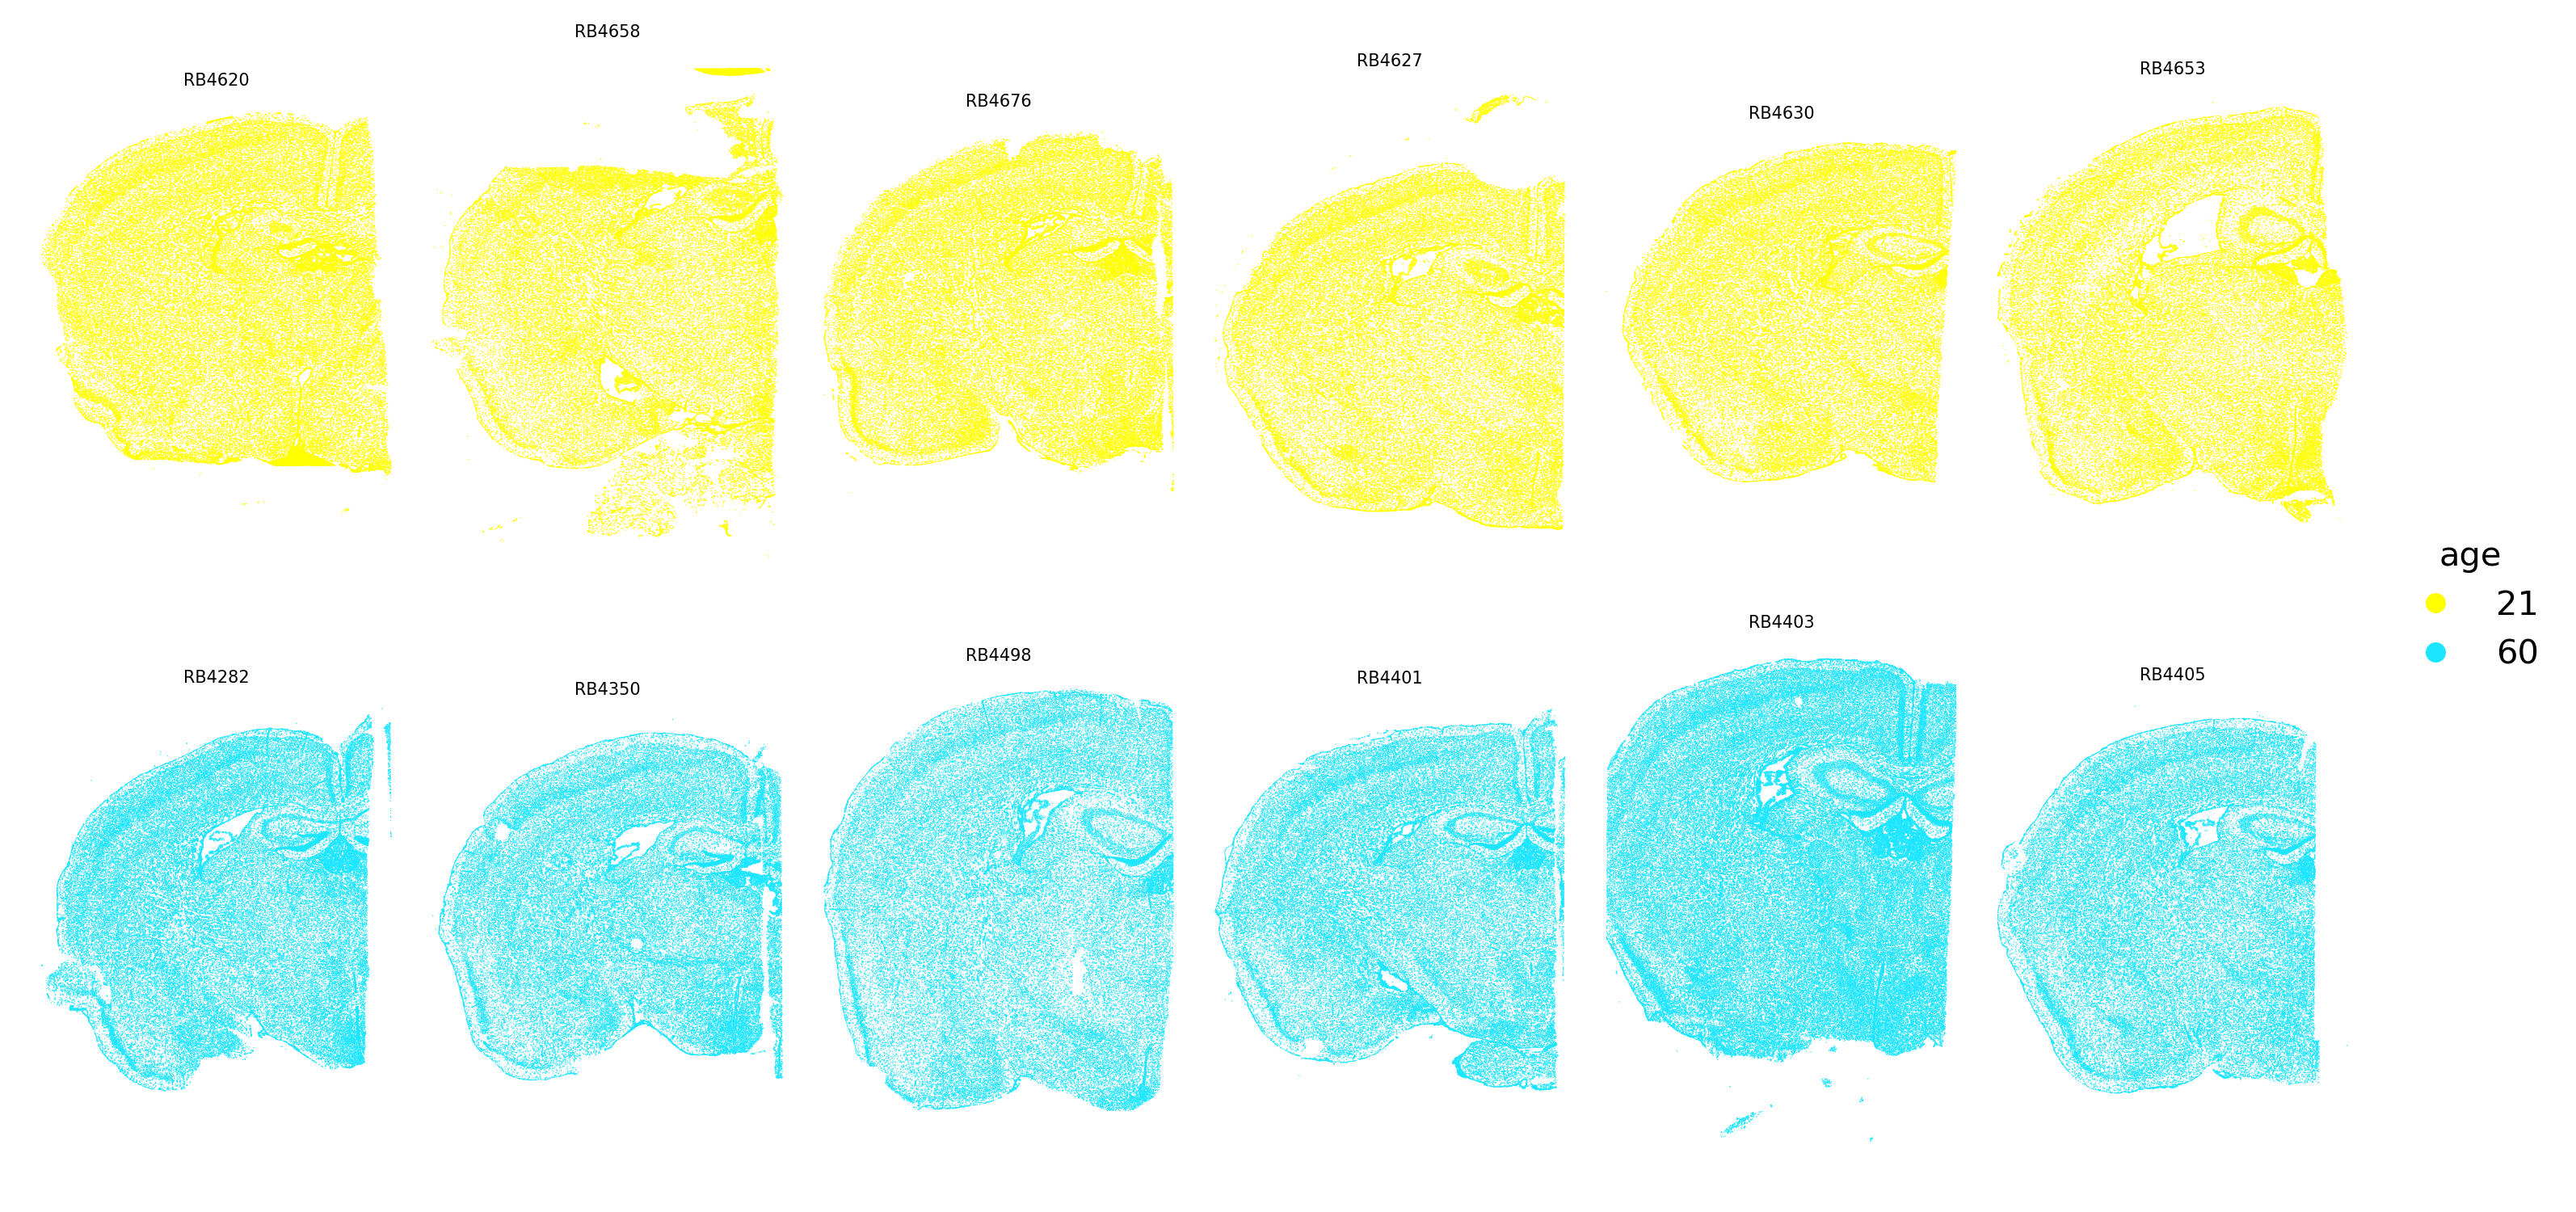

In [43]:
plot_spatial_compact_fast(
    ad,
    color='age',
    groupby='sample_id',  # Adjust to your actual sample column
    spot_size = 0.1,
    cols=6,
    height=5,
    background='white',
    dpi=300
)

/var/folders/5b/5bpdw2nj10d6gxym7gcl01hh0000gp/T/ipykernel_17110/1899192053.py:122: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(col_series):
/var/folders/5b/5bpdw2nj10d6gxym7gcl01hh0000gp/T/ipykernel_17110/1899192053.py:207: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(col_series):
/var/folders/5b/5bpdw2nj10d6gxym7gcl01hh0000gp/T/ipykernel_17110/1899192053.py:281: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if is_categorical_dtype(gser) and gser.cat.ordered:


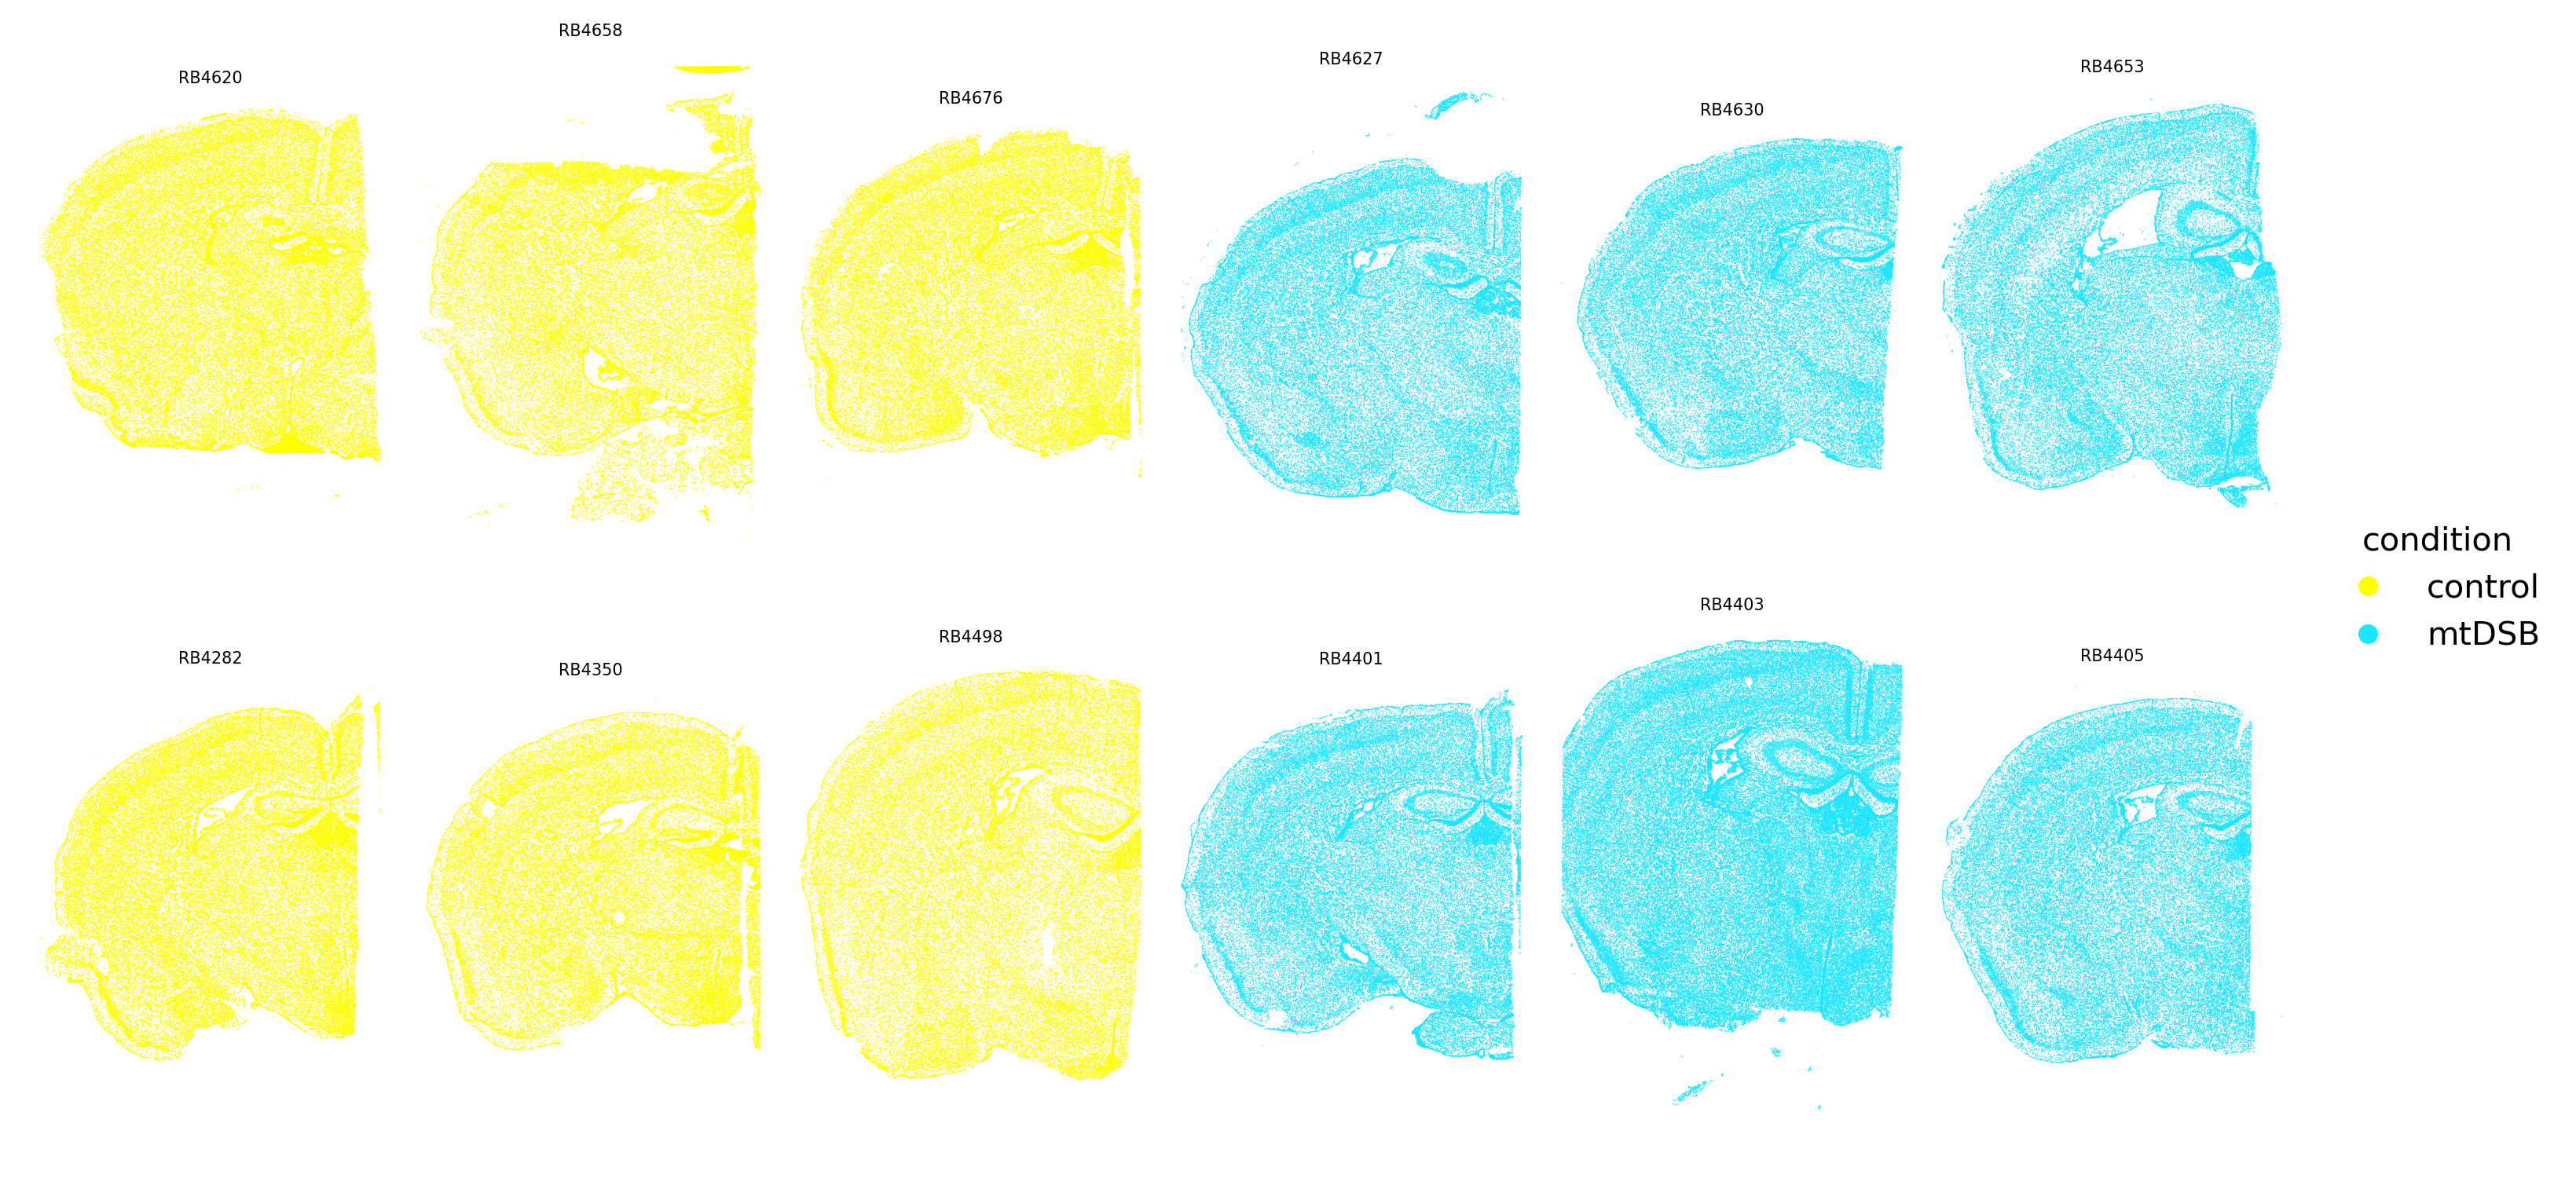

In [44]:
plot_spatial_compact_fast(
    ad,
    color='condition',
    groupby='sample_id',  # Adjust to your actual sample column
    spot_size = 0.1,
    cols=6,
    height=5,
    background='white',
    dpi=300
)